Module 3 - Feature Engineering

Objective

The objective of this phase is to create additional predictive variables using the existing borrower and loan information.

Feature engineering helps transform raw attributes into meaningful business indicators that improve the predictive capability of machine learning models. The engineered features are based on common credit risk assessment practices used in financial institutions.

In [3]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from src.data_loader import load_dataset

risk_df = load_dataset()

print(risk_df.shape)
risk_df.head()

(1345310, 112)


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,target
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,...,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,...,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,...,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0
3,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,...,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N,0
4,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,Veterinary Tecnician,4 years,...,0.0,0.0,16900.0,12798.0,9400.0,4000.0,N,Cash,N,0


Creating Business Features

Instead of using only the original variables, new business features are created to better represent the financial profile of each borrower.

In [5]:
from src.feature_engineering import feature_engineering_pipeline

risk_df = feature_engineering_pipeline(risk_df)

risk_df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,target,loan_income_ratio,installment_income_ratio,fico_average
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,...,7746.0,2400.0,13734.0,N,Cash,N,0,0.065455,0.002237,677.0
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,...,39475.0,79300.0,24667.0,N,Cash,N,0,0.380000,0.012620,717.0
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,...,18696.0,6200.0,14877.0,N,Cash,N,0,0.317460,0.006868,697.0
3,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,...,95768.0,20300.0,88097.0,N,Cash,N,0,0.099585,0.002776,697.0
4,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,Veterinary Tecnician,4 years,...,12798.0,9400.0,4000.0,N,Cash,N,0,0.351471,0.011917,692.0


In [6]:
risk_df[
    [
        "loan_income_ratio",
        "installment_income_ratio",
        "fico_average"
    ]
].head()

,loan_income_ratio,installment_income_ratio,fico_average
0,0.065455,0.002237,677.0
1,0.380000,0.012620,717.0
2,0.317460,0.006868,697.0
3,0.099585,0.002776,697.0
4,0.351471,0.011917,692.0


In [7]:
risk_df[
    [
        "loan_income_ratio",
        "installment_income_ratio",
        "fico_average"
    ]
].describe()

,loan_income_ratio,installment_income_ratio,fico_average
count,1.344949e+06,1.344949e+06,1.345310e+06
mean,3.973574e-01,1.186426e-02,6.981851e+02
std,7.082870e+01,1.970325e+00,3.185284e+01
min,1.714286e-04,5.760000e-06,6.270000e+02
25%,1.246631e-01,3.855085e-03,6.720000e+02
50%,2.000000e-01,6.016642e-03,6.920000e+02
75%,2.909091e-01,8.783500e-03,7.120000e+02
max,4.000000e+04,1.100660e+03,8.475000e+02


In [8]:
risk_df.groupby("target")[
    [
        "loan_income_ratio",
        "installment_income_ratio",
        "fico_average"
    ]
].mean()

,loan_income_ratio,installment_income_ratio,fico_average
target,,,
0,0.407288,0.012139,700.263982
1,0.357543,0.010761,689.850145


In [9]:
risk_df[
    [
        "loan_income_ratio",
        "installment_income_ratio",
        "fico_average",
        "target"
    ]
].corr()

,loan_income_ratio,installment_income_ratio,fico_average,target
loan_income_ratio,1.000000,0.979749,-0.000557,-0.000281
installment_income_ratio,0.979749,1.000000,-0.000784,-0.000280
fico_average,-0.000557,-0.000784,1.000000,-0.130683
target,-0.000281,-0.000280,-0.130683,1.000000


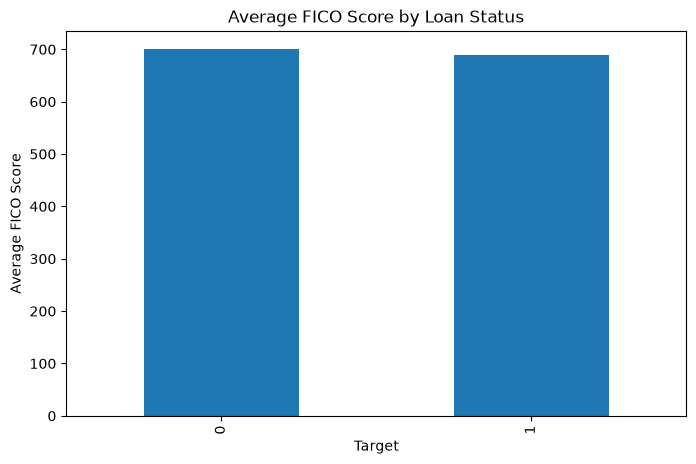

In [10]:
plt.figure(figsize=(8,5))

risk_df.groupby("target")["fico_average"].mean().plot(kind="bar")

plt.title("Average FICO Score by Loan Status")

plt.xlabel("Target")

plt.ylabel("Average FICO Score")

plt.show()

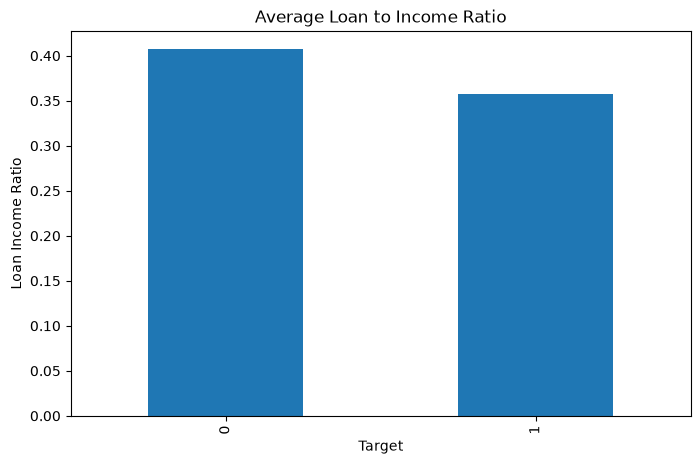

In [11]:
plt.figure(figsize=(8,5))

risk_df.groupby("target")["loan_income_ratio"].mean().plot(kind="bar")

plt.title("Average Loan to Income Ratio")

plt.xlabel("Target")

plt.ylabel("Loan Income Ratio")

plt.show()

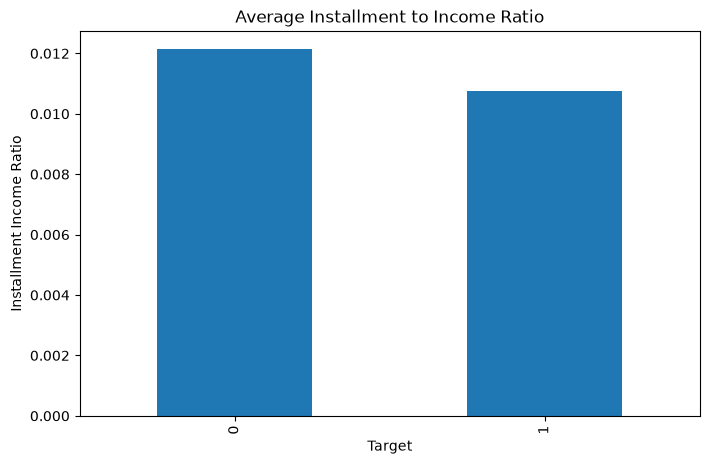

In [12]:
plt.figure(figsize=(8,5))

risk_df.groupby("target")["installment_income_ratio"].mean().plot(kind="bar")

plt.title("Average Installment to Income Ratio")

plt.xlabel("Target")

plt.ylabel("Installment Income Ratio")

plt.show()

In [13]:
risk_df.to_parquet(
    "../data/processed/credit_risk_features.parquet",
    index=False
)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


Observations

Three new business features were created successfully.

- Loan to Income Ratio measures the borrowing burden relative to annual income.
- Installment to Income Ratio estimates the repayment burden.
- Average FICO Score provides a single representation of the borrower's credit quality.

These engineered variables will be used during model development and feature selection.

Feature Engineering Issues and Resolutions

Issue 1 - Division by Zero while Creating Ratio Features

Problem

While creating Loan-to-Income Ratio and Installment-to-Income Ratio, some records produced infinite (`inf`) values.

Root Cause

A small number of borrowers had an annual income equal to zero, causing division by zero during feature creation.

Impact

Infinite values can negatively affect statistical analysis, feature scaling and machine learning algorithms such as Logistic Regression and SVM.

Resolution

The feature engineering function was updated to calculate ratios only when annual income is greater than zero. Otherwise, the value is assigned as `NaN`.

Issue 2 - Extremely Large Ratio Values

Problem

Some ratio features contained unrealistically large values.

Example:

- Loan Income Ratio = 40000
- Installment Income Ratio = 1100

Root Cause

Although division by zero was avoided, several borrowers reported extremely small annual incomes, producing excessively large ratios.

Impact

These extreme observations can distort feature distributions and negatively influence model training.

Planned Resolution

These observations will be handled during the Outlier Treatment phase using IQR-based capping instead of removing records.


Issue 3 - Weak Linear Correlation

Observation

Loan-to-Income Ratio and Installment-to-Income Ratio showed very low Pearson correlation with the target variable.

Interpretation

This does not necessarily imply that the features are unimportant. Credit risk datasets often exhibit non-linear relationships, which tree-based models such as Random Forest and XGBoost can effectively capture.

Therefore, these features will be retained for model training.

In [14]:
ratio_features = [
    "loan_income_ratio",
    "installment_income_ratio"
]

risk_df[ratio_features].describe()

,loan_income_ratio,installment_income_ratio
count,1.344949e+06,1.344949e+06
mean,3.973574e-01,1.186426e-02
std,7.082870e+01,1.970325e+00
min,1.714286e-04,5.760000e-06
25%,1.246631e-01,3.855085e-03
50%,2.000000e-01,6.016642e-03
75%,2.909091e-01,8.783500e-03
max,4.000000e+04,1.100660e+03


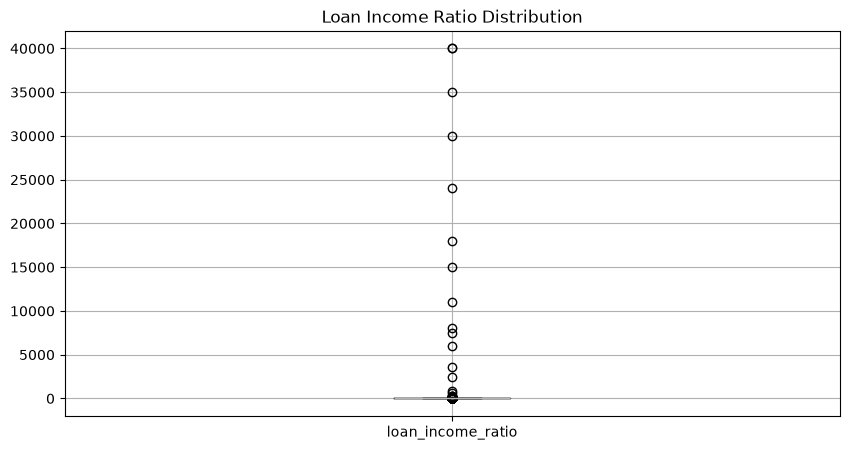

In [15]:
plt.figure(figsize=(10,5))

risk_df.boxplot(column="loan_income_ratio")

plt.title("Loan Income Ratio Distribution")

plt.show()

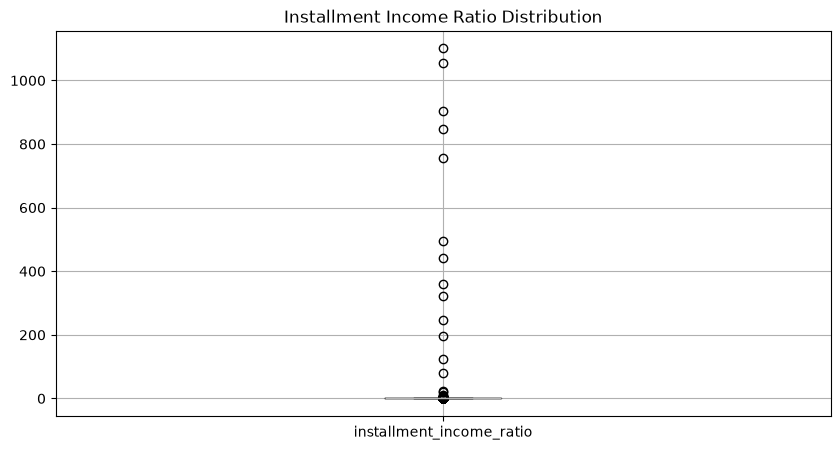

In [16]:
plt.figure(figsize=(10,5))

risk_df.boxplot(column="installment_income_ratio")

plt.title("Installment Income Ratio Distribution")

plt.show()

In [17]:
def cap_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower, upper)

    return df

In [18]:
risk_df = cap_outliers_iqr(
    risk_df,
    "loan_income_ratio"
)

risk_df = cap_outliers_iqr(
    risk_df,
    "installment_income_ratio"
)

In [19]:
risk_df[
    [
        "loan_income_ratio",
        "installment_income_ratio"
    ]
].describe()

,loan_income_ratio,installment_income_ratio
count,1.344949e+06,1.344949e+06
mean,2.135607e-01,6.559247e-03
std,1.144871e-01,3.524075e-03
min,1.714286e-04,5.760000e-06
25%,1.246631e-01,3.855085e-03
50%,2.000000e-01,6.016642e-03
75%,2.909091e-01,8.783500e-03
max,5.402781e-01,1.617612e-02


Issue 4 - Extreme Ratio Feature Outliers

Problem

The engineered ratio features contained extremely large values due to borrowers reporting very small annual incomes.

Evidence

- Maximum Loan-to-Income Ratio: 40000
- Maximum Installment-to-Income Ratio: 1100.66

Impact

These values would dominate feature scaling and negatively affect distance-based and linear machine learning algorithms.

Resolution

Applied IQR-based Winsorization (capping) instead of deleting records.

Result

Loan-to-Income Ratio maximum reduced to approximately 0.54.

Installment-to-Income Ratio maximum reduced to approximately 0.016.

No observations were removed from the dataset.

Feature 4 - Loan Term Flag

Longer repayment terms generally expose lenders to a higher probability of default due to increased uncertainty over time. This feature converts the loan term into a binary risk indicator.

In [20]:
risk_df["term"] = risk_df["term"].str.strip()

risk_df["long_term_loan"] = np.where(
    risk_df["term"]=="60 months",
    1,
    0
)

risk_df["long_term_loan"].value_counts()

long_term_loan
0    1020743
1     324567
Name: count, dtype: int64

Feature 5 - High Revolving Credit Utilization

Borrowers utilizing a high percentage of their revolving credit limits generally exhibit higher financial stress. A utilization above 80% is flagged as high risk.

In [21]:
risk_df["high_revol_util"] = np.where(
    risk_df["revol_util"] >= 80,
    1,
    0
)

risk_df["high_revol_util"].value_counts()

high_revol_util
0    1147151
1     198159
Name: count, dtype: int64

Feature 6 - High Debt-to-Income Ratio

Borrowers with Debt-to-Income ratios above 35% are considered financially stressed and therefore receive a high-risk indicator.

In [22]:
risk_df["high_dti"] = np.where(
    risk_df["dti"] >= 35,
    1,
    0
)

risk_df["high_dti"].value_counts()

high_dti
0    1310284
1      35026
Name: count, dtype: int64

Feature 7 - Prime Borrower Indicator

Borrowers with an average FICO score of at least 720 are classified as Prime Borrowers.

In [23]:
risk_df["prime_borrower"] = np.where(
    risk_df["fico_average"] >= 720,
    1,
    0
)

risk_df["prime_borrower"].value_counts()

prime_borrower
0    1067009
1     278301
Name: count, dtype: int64

Feature 8 - Employment Experience

Employment duration is converted from categorical values into numeric years for easier interpretation by machine learning algorithms.

In [24]:
emp_map = {
    "< 1 year": 0,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10
}

risk_df["emp_years"] = risk_df["emp_length"].map(emp_map)

risk_df["emp_years"].describe()

count    1.345310e+06
mean     6.201301e+00
std      3.704579e+00
min      0.000000e+00
25%      3.000000e+00
50%      7.000000e+00
75%      1.000000e+01
max      1.000000e+01
Name: emp_years, dtype: float64

Feature 9 - Interest Rate Risk Band

Interest rates are grouped into business-friendly risk categories to capture borrower risk levels more effectively than continuous values alone.

In [25]:
risk_df["interest_band"] = pd.cut(
    risk_df["int_rate"],
    bins=[0,10,15,20,40],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

risk_df["interest_band"].value_counts()

interest_band
Medium       553961
Low          375533
High         308692
Very High    107124
Name: count, dtype: int64

In [26]:
risk_df["income_band"] = pd.qcut(
    risk_df["annual_inc"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

risk_df["income_band"].value_counts()

income_band
Medium       362309
Low          336329
Very High    334192
High         312480
Name: count, dtype: int64

In [27]:
risk_df["loan_band"] = pd.qcut(
    risk_df["loan_amnt"],
    q=4,
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large"
    ]
)

risk_df["loan_band"].value_counts()

loan_band
Small         383181
Large         369355
Medium        300914
Very Large    291860
Name: count, dtype: int64

In [28]:
new_features = [
    "loan_income_ratio",
    "installment_income_ratio",
    "fico_average",
    "long_term_loan",
    "high_revol_util",
    "high_dti",
    "prime_borrower",
    "emp_years",
    "interest_band",
    "income_band",
    "loan_band"
]

risk_df[new_features].head()

,loan_income_ratio,installment_income_ratio,fico_average,long_term_loan,high_revol_util,high_dti,prime_borrower,emp_years,interest_band,income_band,loan_band
0,0.065455,0.002237,677.0,0,0,0,0,10,Medium,Medium,Small
1,0.380000,0.012620,717.0,0,0,0,0,10,Medium,Medium,Very Large
2,0.317460,0.006868,697.0,1,0,0,0,10,Medium,Medium,Large
3,0.099585,0.002776,697.0,1,0,0,0,3,Very High,Very High,Medium
4,0.351471,0.011917,692.0,0,0,0,0,4,Medium,Low,Medium


In [29]:
risk_df.groupby("target")[[
    "loan_income_ratio",
    "installment_income_ratio",
    "fico_average",
    "long_term_loan",
    "high_revol_util",
    "high_dti",
    "prime_borrower",
    "emp_years"
]].mean()

,loan_income_ratio,installment_income_ratio,fico_average,long_term_loan,high_revol_util,high_dti,prime_borrower,emp_years
target,,,,,,,,
0,0.205619,0.006345,700.263982,0.203631,0.142155,0.022495,0.228396,6.205362
1,0.245400,0.007419,689.850145,0.392119,0.167907,0.040233,0.120551,6.185017


In [30]:
for feature in [
    "interest_band",
    "income_band",
    "loan_band"
]:
    print(f"\n{feature}")
    print(pd.crosstab(
        risk_df[feature],
        risk_df["target"],
        normalize="index"
    ))


interest_band
target                0         1
interest_band                    
Low            0.918364  0.081636
Medium         0.814128  0.185872
High           0.704437  0.295563
Very High      0.592080  0.407920

income_band
target              0         1
income_band                    
Low          0.767320  0.232680
Medium       0.788617  0.211383
High         0.809130  0.190870
Very High    0.838198  0.161802

loan_band
target             0         1
loan_band                     
Small       0.839431  0.160569
Medium      0.808061  0.191939
Large       0.780493  0.219507
Very Large  0.766330  0.233670


In [31]:
pd.crosstab(
    risk_df["long_term_loan"],
    risk_df["target"],
    normalize="index"
)

target,0,1
long_term_loan,,
0,0.840066,0.159934
1,0.675546,0.324454


In [32]:
print("=" * 50)
print("Final Dataset Summary")
print("=" * 50)

print(f"Rows    : {risk_df.shape[0]}")
print(f"Columns : {risk_df.shape[1]}")

print("\nMissing Values in New Features")
print(
    risk_df[
        [
            "loan_income_ratio",
            "installment_income_ratio",
            "fico_average",
            "long_term_loan",
            "high_revol_util",
            "high_dti",
            "prime_borrower",
            "emp_years",
            "interest_band",
            "income_band",
            "loan_band"
        ]
    ].isnull().sum()
)

print("\nDuplicate Rows :", risk_df.duplicated().sum())

Final Dataset Summary
Rows    : 1345310
Columns : 123

Missing Values in New Features
loan_income_ratio           361
installment_income_ratio    361
fico_average                  0
long_term_loan                0
high_revol_util               0
high_dti                      0
prime_borrower                0
emp_years                     0
interest_band                 0
income_band                   0
loan_band                     0
dtype: int64

Duplicate Rows : 0


In [33]:
risk_df.to_parquet(
    "../data/processed/credit_risk_feature_engineered.parquet",
    index=False
)

print("=" * 50)
print("Feature Engineering Completed Successfully")
print("=" * 50)
print("Dataset saved to:")
print("../data/processed/credit_risk_feature_engineered.parquet")
print(f"Final Shape : {risk_df.shape}")

Feature Engineering Completed Successfully
Dataset saved to:
../data/processed/credit_risk_feature_engineered.parquet
Final Shape : (1345310, 123)


Feature Engineering Summary

Engineered Features

1. Loan Income Ratio
2. Installment Income Ratio
3. Average FICO Score
4. Long Term Loan Flag
5. High Revolving Utilization Flag
6. High Debt-to-Income Flag
7. Prime Borrower Flag
8. Employment Experience (Numeric)
9. Interest Rate Band
10. Income Band
11. Loan Amount Band

Engineering Issues Solved

- Division by zero while creating ratio features.
- Extreme ratio outliers handled using IQR capping.
- Infinite values removed safely.
- Business-driven categorical features created for better model interpretability.
- Continuous financial variables transformed into meaningful risk indicators.

Outcome

A total of 11 engineered features were added to the cleaned dataset. These features capture borrower affordability, repayment burden, creditworthiness, employment stability, loan characteristics and financial risk. The resulting dataset is now ready for categorical encoding, feature scaling and feature selection before model training.